In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [120]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [49]:
# load the data
data = pd.read_csv('Walmart_Sales.csv')

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [51]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## data clearning and processing

In [52]:
data.nunique()

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
dtype: int64

In [53]:
data.duplicated().sum()

0

In [54]:
data.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [55]:
data['Date'].min()

'01-04-2011'

In [56]:
data['Date'].max()

'31-12-2010'

In [57]:
data['DateString'] = data['Date']

In [58]:
data['Date'] = pd.to_datetime(data['DateString'], dayfirst=True)

In [59]:
data['Date'].dt.isocalendar().year

0       2010
1       2010
2       2010
3       2010
4       2010
        ... 
6430    2012
6431    2012
6432    2012
6433    2012
6434    2012
Name: year, Length: 6435, dtype: UInt32

In [60]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,DateString
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,05-02-2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12-02-2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19-02-2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26-02-2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,05-03-2010


In [61]:
data.groupby('Store').count().head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,DateString
Store,,,,,,,,
1,143,143,143,143,143,143,143,143
2,143,143,143,143,143,143,143,143
3,143,143,143,143,143,143,143,143
4,143,143,143,143,143,143,143,143
5,143,143,143,143,143,143,143,143


In [62]:
data = data.sort_values(by=['Store','Date'])

In [ ]:
#data['Year']=data['Date'].dt.year

In [63]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,DateString
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,05-02-2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,12-02-2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,19-02-2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,26-02-2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,05-03-2010


In [145]:
# use slide window to calculate the average sales in the past week, past 4 weeks, and past 12 weeks
data['Past_Week_Sale_Mean'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(1).rolling(window=1).mean()).reset_index(level=0,drop=True)
)

In [81]:
data['Past_Month_Sale_Mean'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(1).rolling(window=4).mean()).reset_index(level=0,drop=True)
)

In [83]:
data['Past_Month_Sale_std'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(1).rolling(window=4).std()).reset_index(level=0,drop=True)
)

In [82]:
data['Past_3Month_Sale_Mean'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(1).rolling(window=12).mean()).reset_index(level=0,drop=True)
)

In [84]:
data['Past_3Month_Sale_std'] = (
    data.groupby('Store')['Weekly_Sales'].apply(lambda s: s.shift(1).rolling(window=12).std()).reset_index(level=0,drop=True)
)

In [309]:
data.dropna(subset =['Past_3Month_Sale_Mean','Past_3Month_Sale_std','Past_Week_Sale_Mean'], inplace=True)

In [310]:
data.isnull().sum()

Store                    0
Date                     0
Weekly_Sales             0
Holiday_Flag             0
Temperature              0
Fuel_Price               0
CPI                      0
Unemployment             0
DateString               0
Past_Month_Sale_Mean     0
Past_3Month_Sale_Mean    0
Past_Month_Sale_std      0
Past_3Month_Sale_std     0
Past_Week_Sale_Mean      0
dtype: int64

In [273]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,DateString,Past_Month_Sale_Mean,Past_3Month_Sale_Mean,Past_Month_Sale_std,Past_3Month_Sale_std,Past_Week_Sale_Mean
12,1,2010-04-30,1425100.71,0,67.41,2.780,210.389546,7.808,30-04-2010,1.499425e+06,1.514695e+06,89550.298266,95107.965230,1448938.92
13,1,2010-05-07,1603955.12,0,72.55,2.835,210.339968,7.808,07-05-2010,1.456958e+06,1.496479e+06,66432.182023,88885.083286,1385065.20
14,1,2010-05-14,1494251.50,0,74.78,2.854,210.337426,7.808,14-05-2010,1.471593e+06,1.493312e+06,93391.490071,83759.904242,1371986.60
15,1,2010-05-21,1399662.07,0,76.44,2.826,210.617093,7.808,21-05-2010,1.478641e+06,1.483503e+06,93897.100217,75039.274445,1605491.78
16,1,2010-05-28,1432069.95,0,80.44,2.759,210.896761,7.808,28-05-2010,1.480742e+06,1.482664e+06,91348.942215,75989.148419,1508237.76


In [ ]:
### outliers?

## EDA

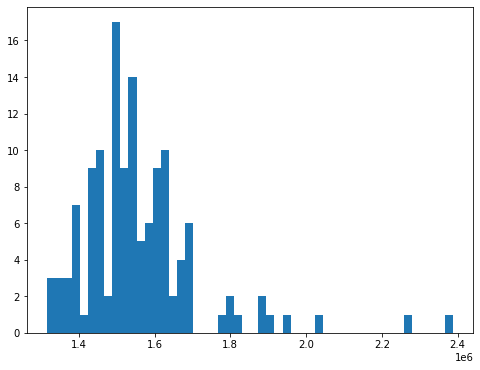

In [137]:
plt.figure(figsize=(8,6))
plt.hist(data.loc[data['Store']==1,'Weekly_Sales'], bins=50)
plt.show()

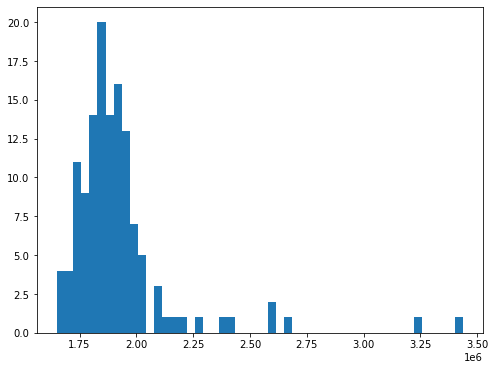

In [138]:
plt.figure(figsize=(8,6))
plt.hist(data.loc[data['Store']==2,'Weekly_Sales'], bins=50)
plt.show()

In [274]:
data.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'DateString',
       'Past_Month_Sale_Mean', 'Past_3Month_Sale_Mean', 'Past_Month_Sale_std',
       'Past_3Month_Sale_std', 'Past_Week_Sale_Mean'],
      dtype='object')

In [280]:
numerical_features = ['Temperature','Fuel_Price', 'CPI', 'Unemployment', 'Past_Month_Sale_Mean', \
                      'Past_3Month_Sale_Mean', 'Past_Month_Sale_std', 'Past_3Month_Sale_std', 'Past_Week_Sale_Mean']
categorical_features = ['Store','Holiday_Flag']

In [276]:
target=['Weekly_Sales']

In [149]:
selected_columns = numerical_features +target

In [150]:
data[selected_columns].corr(method='pearson')

,Temperature,Fuel_Price,CPI,Unemployment,Past_Month_Sale_Mean,Past_3Month_Sale_Mean,Past_Month_Sale_std,Past_3Month_Sale_std,Past_Week_Sale_Mean,Weekly_Sales
Temperature,1.000000,0.058971,0.173949,0.120297,-0.075547,-0.073656,-0.381786,-0.513230,0.033527,-0.068351
Fuel_Price,0.058971,1.000000,-0.187669,-0.011937,0.007243,0.015171,-0.070688,-0.019168,-0.014067,0.005998
CPI,0.173949,-0.187669,1.000000,-0.294201,-0.073254,-0.073921,-0.081842,-0.095462,-0.013369,-0.071739
Unemployment,0.120297,-0.011937,-0.294201,1.000000,-0.116963,-0.118766,-0.002857,-0.043237,0.118576,-0.113348
Past_Month_Sale_Mean,-0.075547,0.007243,-0.073254,-0.116963,1.000000,0.985847,0.496357,0.528103,0.120871,0.958246
Past_3Month_Sale_Mean,-0.073656,0.015171,-0.073921,-0.118766,0.985847,1.000000,0.429490,0.556166,0.121323,0.952535
Past_Month_Sale_std,-0.381786,-0.070688,-0.081842,-0.002857,0.496357,0.429490,1.000000,0.649273,0.031303,0.366319
Past_3Month_Sale_std,-0.513230,-0.019168,-0.095462,-0.043237,0.528103,0.556166,0.649273,1.000000,0.045265,0.465179
Past_Week_Sale_Mean,0.033527,-0.014067,-0.013369,0.118576,0.120871,0.121323,0.031303,0.045265,1.000000,0.121726
Weekly_Sales,-0.068351,0.005998,-0.071739,-0.113348,0.958246,0.952535,0.366319,0.465179,0.121726,1.000000


## Feature Transforming

In [ ]:
## data split

In [281]:
features = numerical_features +categorical_features

In [282]:
data['Date'].unique()[85]

numpy.datetime64('2011-12-16T00:00:00.000000000')

In [311]:
#split by time 2011-12-16
X_train = data[data['Date']<'2011-12-16'][features]
y_train = data[data['Date']<'2011-12-16'][target]

In [312]:
X_test = data[data['Date']>'2011-12-16'][features]
y_test = data[data['Date']>'2011-12-16'][target]

In [ ]:
# process categorical_features

In [119]:
categorical_features

['Store', 'Holiday_Flag']

In [ ]:
#One hot encoding categorical features

In [122]:
encoder = OneHotEncoder(handle_unknown='error', drop='first')

In [123]:
encoder.fit(X_train[categorical_features])

OneHotEncoder(drop='first')

In [127]:
encoder.transform(X_train[categorical_features]).toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [130]:
encoder.get_feature_names()

array(['x0_2', 'x0_3', 'x0_4', 'x0_5', 'x0_6', 'x0_7', 'x0_8', 'x0_9',
       'x0_10', 'x0_11', 'x0_12', 'x0_13', 'x0_14', 'x0_15', 'x0_16',
       'x0_17', 'x0_18', 'x0_19', 'x0_20', 'x0_21', 'x0_22', 'x0_23',
       'x0_24', 'x0_25', 'x0_26', 'x0_27', 'x0_28', 'x0_29', 'x0_30',
       'x0_31', 'x0_32', 'x0_33', 'x0_34', 'x0_35', 'x0_36', 'x0_37',
       'x0_38', 'x0_39', 'x0_40', 'x0_41', 'x0_42', 'x0_43', 'x0_44',
       'x0_45', 'x1_1'], dtype=object)

In [131]:
X_train_categorical_processed = pd.DataFrame(encoder.transform(X_train[categorical_features]).toarray(), columns=encoder.get_feature_names())

In [133]:
X_test_categorical_processed = pd.DataFrame(encoder.transform(X_test[categorical_features]).toarray(), columns=encoder.get_feature_names())

In [301]:
#encoder.get_feature_names(categorical_features)

In [134]:
# handle numerical featues
scaler = StandardScaler()

In [139]:
scaler.fit(X_train[numerical_features])

StandardScaler()

In [140]:
X_train_numerical_processed = pd.DataFrame(scaler.transform(X_train[numerical_features]), columns = numerical_features)

In [141]:
X_test_numerical_processed = pd.DataFrame(scaler.transform(X_test[numerical_features]), columns = numerical_features)

In [176]:
#merge data set
X_train_processed = pd.concat([X_train_numerical_processed,X_train_categorical_processed], axis=1 )

In [177]:
X_test_processed = pd.concat([X_test_numerical_processed,X_test_categorical_processed], axis=1 )

## Modelling

In [161]:
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, mean_absolute_error

In [169]:
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet

In [198]:
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV, GridSearchCV, RepeatedKFold

In [241]:
import xgboost as xgb

In [ ]:
#RepeatedStratifiedKFold is for classification

In [ ]:
#Baseline

In [151]:
y_test_baseline = data[data['Date']>'2011-12-16']['Past_Month_Sale_Mean']

In [164]:
y_test

,Weekly_Sales
98,2270188.99
99,1497462.72
100,1550369.92
101,1459601.17
102,1394393.84
...,...
6430,713173.95
6431,733455.07
6432,734464.36
6433,718125.53


In [165]:
y_test_baseline

98      1.824566e+06
99      1.883783e+06
100     1.862128e+06
101     1.799800e+06
102     1.694406e+06
            ...     
6430    7.315338e+05
6431    7.262528e+05
6432    7.179884e+05
6433    7.260449e+05
6434    7.248047e+05
Name: Past_Month_Sale_Mean, Length: 2025, dtype: float64

In [159]:
r2_score(y_test, y_test_baseline)

0.9183771935852734

In [163]:
mean_squared_error(y_test, y_test_baseline)

25495008728.358192

In [166]:
mean_squared_error(y_test, y_test_baseline, squared=False)

159671.56518415603

In [ ]:
#linear regression

In [170]:
model = ElasticNet()

In [184]:
#define search space
space = dict()
space['l1_ratio']=[0.1,0.5,0.7]

In [199]:
#cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats=1, random_state = 42)#This is for classification only
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

In [200]:
search = GridSearchCV(model, space, scoring='neg_root_mean_squared_error', cv=cv)

In [201]:
results = search.fit(X_train_processed, y_train)

In [203]:
results.best_params_

{'l1_ratio': 0.7}

In [204]:
results.best_score_

-175776.40282357007

In [206]:
results.cv_results_

{'mean_fit_time': array([0.00584135, 0.00536571, 0.00606394]),
 'std_fit_time': array([0.00107702, 0.00024811, 0.00035316]),
 'mean_score_time': array([0.00267177, 0.00227208, 0.00224242]),
 'std_score_time': array([0.00039269, 0.0001104 , 0.00020784]),
 'param_l1_ratio': masked_array(data=[0.1, 0.5, 0.7],
              mask=[False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'l1_ratio': 0.1}, {'l1_ratio': 0.5}, {'l1_ratio': 0.7}],
 'split0_test_score': array([-248543.80657807, -208537.86117142, -185987.09661146]),
 'split1_test_score': array([-237000.2844387 , -201176.26147298, -180730.4599451 ]),
 'split2_test_score': array([-223142.39666348, -184765.26422782, -163767.307262  ]),
 'split3_test_score': array([-220722.40549605, -178550.27280123, -155425.32408207]),
 'split4_test_score': array([-256789.87590866, -215963.16493294, -192851.33582852]),
 'split5_test_score': array([-227357.98746229, -187322.78033349, -164949.7853229 ]),
 'split6_test_scor

In [207]:
best_model = search.best_estimator_

In [209]:
y_test_pred = best_model.predict(X_test_processed)

In [211]:
mean_squared_error(y_test, y_test_pred, squared=False)

160618.74148860975

In [ ]:
#xgb regression

In [248]:
model = xgb.XGBRegressor(objective='reg:squarederror', importance_type='gain')

In [249]:
#define search space
space = dict()
space['n_estimators']=[5, 10, 20]
space['max_depth']=[3,6,8]

In [250]:
cv = RepeatedKFold(n_splits = 5, n_repeats=1, random_state=42)

In [251]:
search = GridSearchCV(model,space,scoring='neg_root_mean_squared_error', cv=cv)

In [252]:
results = search.fit(X_train_processed, y_train)

In [253]:
#results.cv_results_
results.best_params_

{'max_depth': 8, 'n_estimators': 20}

In [254]:
results.best_score_

-111762.04448361338

In [255]:
best_model_xgb = results.best_estimator_

In [256]:
y_test_pred = best_model_xgb.predict(X_test_processed)

In [257]:
mean_squared_error(y_test, y_test_pred, squared=False)

114838.21054747741

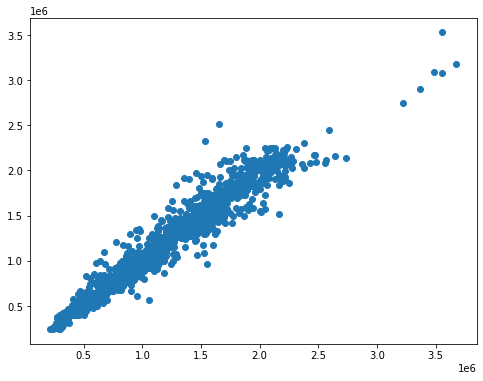

In [258]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_test_pred)
plt.show()

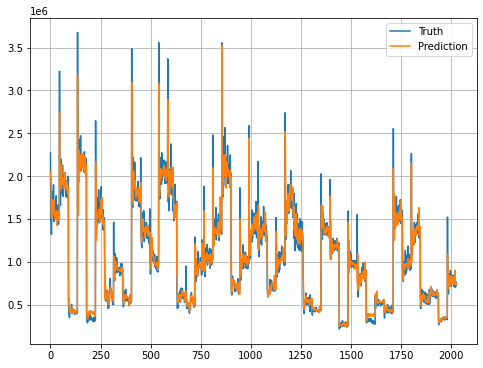

In [259]:
plt.figure(figsize=(8,6))
plt.plot(range(len(y_test)), y_test, label='Truth')
plt.plot(range(len(y_test)), y_test_pred, label='Prediction')
plt.legend()
plt.grid()
plt.show()

In [237]:
#Feature importance
best_model_xgb.feature_importances_  #based on average gain

array([3.7144918e-03, 2.4007056e-03, 2.1967434e-03, 2.6179790e-03,
       8.7358695e-01, 6.8885055e-03, 1.4365245e-02, 7.4985158e-03,
       1.7859123e-04, 0.0000000e+00, 3.6277329e-03, 0.0000000e+00,
       4.0585781e-03, 1.7543889e-03, 7.2769327e-03, 6.7721005e-05,
       1.6178250e-03, 0.0000000e+00, 7.8567700e-04, 2.6999542e-03,
       9.0029661e-04, 5.9002597e-04, 4.0202081e-04, 1.7110620e-03,
       2.7656169e-03, 9.4952033e-04, 0.0000000e+00, 2.5840490e-03,
       1.4640501e-03, 2.7092786e-03, 4.2577740e-03, 1.2930504e-03,
       0.0000000e+00, 6.6343206e-03, 2.1828653e-03, 2.3652792e-03,
       0.0000000e+00, 1.2624628e-03, 3.5588711e-04, 5.9386319e-04,
       5.7016365e-04, 2.8897419e-03, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 1.6709256e-03, 0.0000000e+00, 6.6501610e-03,
       5.9239072e-04, 0.0000000e+00, 0.0000000e+00, 7.4012205e-04,
       1.8528530e-02], dtype=float32)

In [260]:
feature_importance = pd.DataFrame()
feature_importance['feature']=X_train_processed.columns
feature_importance['importance']=best_model_xgb.feature_importances_
feature_importance.sort_values(by='importance', ascending=False).head()

,feature,importance
4,Past_Month_Sale_Mean,0.873587
52,x1_1,0.018529
6,Past_Month_Sale_std,0.014365
7,Past_3Month_Sale_std,0.007499
14,x0_8,0.007277


In [242]:
feature_importance = pd.DataFrame()
feature_importance['feature']=X_train_processed.columns
feature_importance['importance']=best_model_xgb.feature_importances_
feature_importance.sort_values(by='importance', ascending=False).head()

,feature,importance
4,Past_Month_Sale_Mean,0.873587
52,x1_1,0.018529
6,Past_Month_Sale_std,0.014365
7,Past_3Month_Sale_std,0.007499
14,x0_8,0.007277


In [261]:
feature_importance.sort_values(by='importance', ascending=False).head(10)

,feature,importance
4,Past_Month_Sale_Mean,0.873587
52,x1_1,0.018529
6,Past_Month_Sale_std,0.014365
7,Past_3Month_Sale_std,0.007499
14,x0_8,0.007277
5,Past_3Month_Sale_Mean,0.006889
47,x0_41,0.006650
33,x0_27,0.006634
30,x0_24,0.004258
12,x0_6,0.004059


## A faster way to process the data

In [262]:
from sklearn.compose import ColumnTransformer

In [265]:
preprocessor = ColumnTransformer([
    ('num_features', StandardScaler(), numerical_features),
    ('categorical_features', OneHotEncoder(handle_unknown='error', drop='first'), categorical_features)
]
)

In [286]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('num_features', StandardScaler(),
                                 ['Temperature', 'Fuel_Price', 'CPI',
                                  'Unemployment', 'Past_Month_Sale_Mean',
                                  'Past_3Month_Sale_Mean',
                                  'Past_Month_Sale_std', 'Past_3Month_Sale_std',
                                  'Past_Week_Sale_Mean']),
                                ('categorical_features',
                                 OneHotEncoder(drop='first'),
                                 ['Store', 'Holiday_Flag'])])

In [287]:
X_train_processed = preprocessor.transform(X_train)

In [291]:
X_train_processed

<3825x54 sparse matrix of type '<class 'numpy.float64'>'
	with 38435 stored elements in Compressed Sparse Row format>

In [290]:
X_train_processed.toarray()

array([[ 0.2884252 , -1.10284761,  1.04376616, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.56314415, -0.97770011,  1.04248355, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.68233155, -0.93446734,  1.04241777, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.71103867,  0.51724359,  0.47358881, ...,  0.        ,
         1.        ,  1.        ],
       [-0.63193672,  0.42622723,  0.47752211, ...,  0.        ,
         1.        ,  0.        ],
       [-0.82541582,  0.3420371 ,  0.48145542, ...,  0.        ,
         1.        ,  0.        ]])

In [297]:
feature_names = (
    numerical_features +
    preprocessor.named_transformers_['categorical_features'].get_feature_names(categorical_features).tolist()
)

## Use pipeline

In [303]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.model_selection import cross_val_score

In [328]:
model = xgb.XGBRegressor(objective='reg:squarederror', importance_type='gain')

In [317]:
pipe = Pipeline([('Preprocess', preprocessor),
                 ('regressor', model)  
    ])

In [329]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(transformers=[('num_features',
                                                  StandardScaler(),
                                                  ['Temperature', 'Fuel_Price',
                                                   'CPI', 'Unemployment',
                                                   'Past_Month_Sale_Mean',
                                                   'Past_3Month_Sale_Mean',
                                                   'Past_Month_Sale_std',
                                                   'Past_3Month_Sale_std',
                                                   'Past_Week_Sale_Mean']),
                                                 ('categorical_features',
                                                  OneHotEncoder(drop='first'),
                                                  ['Store', 'Holiday_Flag'])])),
                ('regress...
                              gamma=0, gpu

In [330]:
y_predict = pipe.predict(X_train)

In [331]:
#define search space
space = dict()
space['regressor__n_estimators']=[5, 10, 20]
space['regressor__max_depth']=[3,6,8]

In [332]:
cv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=42)

In [333]:
search=GridSearchCV(pipe, space,scoring='neg_root_mean_squared_error', cv =cv)

In [334]:
results = search.fit(X_train, y_train)

In [335]:
results.best_score_

-116068.82286774316

In [336]:
results.best_params_

{'regressor__max_depth': 6, 'regressor__n_estimators': 20}